# REI-TuRBO Benchmark Test

In [1]:
# Import necessary libraries
import warnings, os, torch, copy

os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optimpv import FitParam
from optimpv.models.HPA import HPAAgent, HPAModel
from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer

plt.style.use('default')

## Benchmark Setup

Information about the HPA(human-powered aircraft) can be found here: https://github.com/Nobuo-Namura/hpa

In [ ]:
# Main notebook setup
# change these parameters to run different problems with varying number of dimensions -> n_div and level
problem_name = 'HPA101' # HPA101, HPA102, HPA103
n_div = 4
level = 0
normalized = True

total_evaluations = 60
n_init = 20
batch_size = 2
seed = np.random.randint(0, 10000) 

# add the variations, list of name, method -> reiturbo or turbo, acquisition function -> ts or ei, and number of trust regions for reiturbo
variations = [
    {'label': 'TuRBO-1 - TS', 'method': 'turbo', 'acq': 'ts'},
    {'label': 'TuRBO-1 - EI', 'method': 'turbo', 'acq': 'ei'},
    {'label': 'REI-TuRBO-1 - TS', 'method': 'reiturbo', 'acq': 'ts', 'n_trust_regions': 1},
    {'label': 'REI-TuRBO-1 - EI', 'method': 'reiturbo', 'acq': 'ei', 'n_trust_regions': 1},
    {'label': 'REI-TuRBO-2 - EI', 'method': 'reiturbo', 'acq': 'ei', 'n_trust_regions': 2},
    {'label': 'REI-TuRBO-4 - EI', 'method': 'reiturbo', 'acq': 'ei', 'n_trust_regions': 4},
]

print(f'Problem: {problem_name}-{level}')
print(f'Total evaluations per variation: {total_evaluations * batch_size}')
print(f'Seed: {seed}')
print('variations:')
for variation in variations:
    print('  -', variation['label'])

Problem: HPA101-0
Total evaluations per variation: 60
Seed: 2
variations:
  - TuRBO-1 - TS
  - TuRBO-1 - EI
  - REI-TuRBO-1 - TS
  - REI-TuRBO-1 - EI
  - REI-TuRBO-2 - EI
  - REI-TuRBO-4 - EI


In [3]:
# Build the HPA benchmark model and define the optimization parameters
hpa_model = HPAModel(
    problem_name=problem_name,
    n_div=n_div,
    level=level,
    normalized=normalized,
)

params = []
for i in range(hpa_model.nx):
    params.append(
        FitParam(
            name=f'x{i}',
            value=0.5,
            bounds=[0.0, 1.0],
            value_type='float',
            type='range',
            display_name=f'x{i}',
            axis_type='linear',
        )
    )

print(f'Dimension: {hpa_model.nx}D')
print(f'Number of objectives: {hpa_model.nf}')
print(f'Number of explicit constraints: {hpa_model.ng}')
print(f'Initial midpoint objective: {hpa_model.evaluate(np.full(hpa_model.nx, 0.5))[0][0]:.6f}')

Dimension: 17D
Number of objectives: 1
Number of explicit constraints: 0
Initial midpoint objective: 26.070936


In [4]:
# Define the Agent and the target metric/loss function
hpa_agent = HPAAgent(
    params=params,
    problem_name=problem_name,
    n_div=n_div,
    level=level,
    normalized=normalized,
    metric='obj',
    loss='linear',
    minimize=True,
    name='hpa101',
)

print('Agent metric name:', hpa_agent.all_agent_metrics)

Agent metric name: ['hpa101_HPA101_obj_linear']


In [ ]:
import time

#put the optimizer building into functions along with the history data extraction

def build_optimizer(variation, seed=0):
    params_local = copy.deepcopy(params)
    agent_local = HPAAgent(
        params=params_local,
        problem_name=problem_name,
        n_div=n_div,
        level=level,
        normalized=normalized,
        metric='obj',
        loss='linear',
        minimize=True,
        name='hpa101',
    )

    if variation['method'] == 'turbo':
        model_kwargs_list = [
            {},
            {
                'torch_device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
                'torch_dtype': torch.double,
                'acq': variation['acq'],
                'seed': seed,
            },
        ]
        models = ['SOBOL', 'TURBO']
    elif variation['method'] == 'reiturbo':
        model_kwargs_list = [
            {},
            {
                'torch_device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
                'torch_dtype': torch.double,
                'acq': variation['acq'],
                'n_trust_regions': variation['n_trust_regions'],
                'region_init_points': 4,
                'racqf': 'REI',
                'seed': seed,
            },
        ]
        models = ['SOBOL', 'REITURBO']
    else:
        raise ValueError(f"Unknown method: {variation['method']}")

    return axBOtorchOptimizer(
        params=params_local,
        agents=agent_local,
        models=models,
        n_batches=[1, total_evaluations - n_init],
        batch_size=[n_init, batch_size],
        model_kwargs_list=model_kwargs_list,
        max_parallelism=1,
        verbose_logging=True,
    )


def extract_history(optimizer):
    df = optimizer.ax_client._experiment.lookup_data().df.copy()
    metric_name = df['metric_name'].iloc[0]
    hist = (
        df[df['metric_name'] == metric_name]
        .sort_values('trial_index')
        .loc[:, ['trial_index', 'mean']]
        .reset_index(drop=True)
    )
    hist['evaluation'] = np.arange(1, len(hist) + 1)
    hist['best_obj_val'] = hist['mean'].cummin()
    return hist, metric_name

def run_variation(variation, seed=0):
    optimizer = build_optimizer(variation=variation, seed=seed)
    start_time = time.time()
    optimizer.optimize()
    end_time = time.time() - start_time
    history, metric_name = extract_history(optimizer)
    return {
        'label': variation['label'],
        'history': history,
        'metric_name': metric_name,
        'runtime': end_time,
        'best_value': float(history['best_obj_val'].iloc[-1]),
    }

## Run All Six Variations

In [ ]:
runs = []
for variation in variations:
    print(f"Running {variation['label']}") # set verbose logging = False to see just the prints
    runs.append(run_variation(variation, seed=seed))

Running TuRBO-1 - TS


[INFO 03-30 14:50:38] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'x0': 0.18759688455611467, 'x1': 0.6815907340496778, 'x2': 0.24979293812066317, 'x3': 0.5538059715181589, 'x4': 0.5002287933602929, 'x5': 0.8828163677826524, 'x6': 0.3340269001200795, 'x7': 0.2531134122982621, 'x8': 0.7734045395627618, 'x9': 0.8693369049578905, 'x10': 0.9834846397861838, 'x11': 0.5694151297211647, 'x12': 0.3404778577387333, 'x13': 0.4475352354347706, 'x14': 0.8192664608359337, 'x15': 0.874193393625319, 'x16': 0.6554301911965013}
[INFO 03-30 14:50:38] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'x0': 0.8058078149333596, 'x1': 0.19691606517881155, 'x2': 0.8665591133758426, 'x3': 0.4806152703240514, 'x4': 0.19392444286495447, 'x5': 0.2102220756933093, 'x6': 0.6794810397550464, 'x7': 0.8904452240094543, 'x8': 0.4098592037335038, 'x9': 0.29759706649929285, 'x10': 0.18001029454171658, 'x11': 0.32632345240563154, 'x12': 0.8581398036330938, 'x13': 0.7048569591715932, 'x14': 0.4554700488224625

Running TuRBO-1 - EI


[INFO 03-30 14:52:30] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'x0': 0.8232106510549784, 'x1': 0.8162878192961216, 'x2': 0.9176690299063921, 'x3': 0.4306651456281543, 'x4': 0.7233794527128339, 'x5': 0.41486067324876785, 'x6': 0.021425988525152206, 'x7': 0.09998165164142847, 'x8': 0.930284108966589, 'x9': 0.12769237160682678, 'x10': 0.30350280925631523, 'x11': 0.3933501457795501, 'x12': 0.779725999571383, 'x13': 0.12082377169281244, 'x14': 0.07175696268677711, 'x15': 0.6582312257960439, 'x16': 0.36710729729384184}
[INFO 03-30 14:52:30] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'x0': 0.03600088879466057, 'x1': 0.03542233631014824, 'x2': 0.1711642574518919, 'x3': 0.8576739728450775, 'x4': 0.27442511543631554, 'x5': 0.8073300393298268, 'x6': 0.5773963378742337, 'x7': 0.6747270729392767, 'x8': 0.3807497192174196, 'x9': 0.6323783798143268, 'x10': 0.8159338375553489, 'x11': 0.7471062364056706, 'x12': 0.41826577857136726, 'x13': 0.891985340975225, 'x14': 0.597910035401

Running REI-TuRBO-1 - TS


...

[INFO 03-30 14:56:09] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'x0': 0.934235674329102, 'x1': 0.4251715885475278, 'x2': 0.025864899158477783, 'x3': 0.5599940763786435, 'x4': 0.19683574698865414, 'x5': 0.30824606865644455, 'x6': 0.12131120078265667, 'x7': 0.830513184890151, 'x8': 0.9865408381447196, 'x9': 0.4268086077645421, 'x10': 0.41426409874111414, 'x11': 0.34075369872152805, 'x12': 0.19860214181244373, 'x13': 0.37398591078817844, 'x14': 0.2312573967501521, 'x15': 0.0516588082537055, 'x16': 0.029867266304790974}
[INFO 03-30 14:56:09] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'x0': 0.290960606187582, 'x1': 0.779737520031631, 'x2': 0.907523107714951, 'x3': 0.36130538024008274, 'x4': 0.7729237740859389, 'x5': 0.5789679521694779, 'x6': 0.8471713932231069, 'x7': 0.35344768688082695, 'x8': 0.42595092486590147, 'x9': 0.6071066092699766, 'x10': 0.630843648687005, 'x11': 0.6179754361510277, 'x12': 0.5010681906715035, 'x13': 0.9419983997941017, 'x14': 0.72895653173327

Running REI-TuRBO-2 - EI


[INFO 03-30 14:57:24] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'x0': 0.559121323749423, 'x1': 0.17048378102481365, 'x2': 0.7576165003702044, 'x3': 0.3838482154533267, 'x4': 0.15211329981684685, 'x5': 0.4417696828022599, 'x6': 0.6953017134219408, 'x7': 0.7184040416032076, 'x8': 0.5420038336887956, 'x9': 0.9426433425396681, 'x10': 0.15818831697106361, 'x11': 0.5672339545562863, 'x12': 0.16370641067624092, 'x13': 0.36716122832149267, 'x14': 0.7372097438201308, 'x15': 0.024901057593524456, 'x16': 0.37326325196772814}
[INFO 03-30 14:57:24] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'x0': 0.40497829392552376, 'x1': 0.510694170370698, 'x2': 0.2405965905636549, 'x3': 0.6708869244903326, 'x4': 0.9877639701589942, 'x5': 0.8689116891473532, 'x6': 0.19853575527668, 'x7': 0.3290483979508281, 'x8': 0.22930994164198637, 'x9': 0.27154502645134926, 'x10': 0.8465050226077437, 'x11': 0.4890416581183672, 'x12': 0.7972407573834062, 'x13': 0.741958025842905, 'x14': 0.2915649246424436

Running REI-TuRBO-4 - EI


[INFO 03-30 14:59:02] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'x0': 0.835803683847189, 'x1': 0.4611552618443966, 'x2': 0.052118013612926006, 'x3': 0.341345202177763, 'x4': 0.0776865016669035, 'x5': 0.7922725426033139, 'x6': 0.10618922207504511, 'x7': 0.6917389435693622, 'x8': 0.6378545677289367, 'x9': 0.6769162621349096, 'x10': 0.5195207241922617, 'x11': 0.46129469759762287, 'x12': 0.456976231187582, 'x13': 0.03944447822868824, 'x14': 0.4131708098575473, 'x15': 0.6897957576438785, 'x16': 0.44208197947591543}
[INFO 03-30 14:59:02] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'x0': 0.39871208276599646, 'x1': 0.7929385174065828, 'x2': 0.9710291232913733, 'x3': 0.6654458288103342, 'x4': 0.7379652801901102, 'x5': 0.009883923456072807, 'x6': 0.514032443985343, 'x7': 0.4398091407492757, 'x8': 0.46816494408994913, 'x9': 0.05939006060361862, 'x10': 0.32510548271238804, 'x11': 0.5410573529079556, 'x12': 0.6109800701960921, 'x13': 0.871366067789495, 'x14': 0.569927638396620

In [7]:
summary_df = pd.DataFrame(
    {
        'variation': run['label'],
        'runtime': run['runtime'],
        'best_value': run['best_value'],
    }
    for run in runs
).sort_values('best_value').reset_index(drop=True)

summary_df

,variation,runtime,best_value
0,REI-TuRBO-1 - TS,56.103755,23.109728
1,REI-TuRBO-1 - EI,74.613789,23.163629
2,REI-TuRBO-2 - EI,97.525325,23.306925
3,REI-TuRBO-4 - EI,235.707726,23.727632
4,TuRBO-1 - TS,112.535235,23.804416
5,TuRBO-1 - EI,162.756110,24.189902


## Comparison Plot

Best-so-far objective values of each variation.

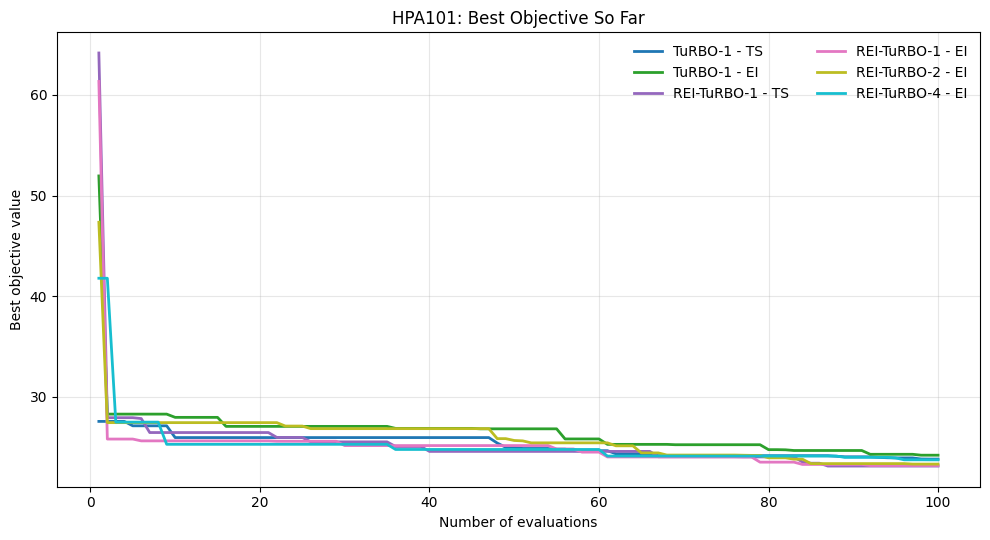

In [8]:
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(runs)))

fig, ax = plt.subplots(figsize=(10, 5.5))

for color, run in zip(colors, runs):
    hist = run['history']
    ax.plot(
        hist['evaluation'],
        hist['best_obj_val'],
        color=color,
        lw=2.0,
        label=run['label'],
    )

ax.set_title('HPA101: Best Objective So Far')
ax.set_xlabel('Number of evaluations')
ax.set_ylabel('Best objective value')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', frameon=False, ncol=2)

plt.tight_layout()
plt.show()
